# Week 5 - Expectation Maximization and Principal Component Analysis

Learning contents:

1. Mixture of Gaussians: Expectation-Maximization
    - Display results
    - Nearest Centroid-based classification
2. Principal Component Analysis
    - Generate data
    - Apply PCA
    - Display projection

## Dependencies

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import multivariate_normal, norm
from sklearn import datasets
from IPython.display import HTML

import seaborn as sns; sns.set_theme(); sns.set_palette('bright')

## Generate Data

#### We use `iris` dataset from `sklearn` library

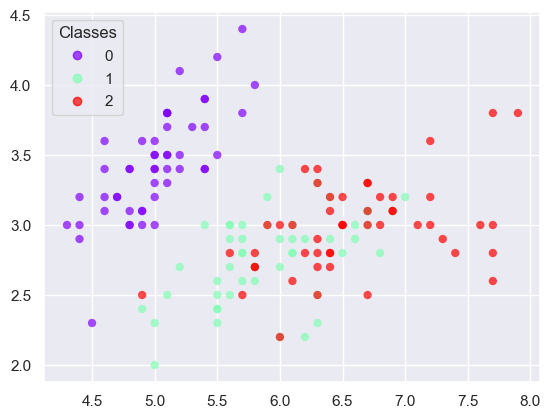

In [33]:
iris = datasets.load_iris()
iris_x = np.array(iris.data[:, :2])  # we only take the first two features.
iris_t = np.array(iris.target)

def plot_iris(legend=True, classes=iris_t, target=plt):
    scatter = target.scatter(iris_x[:, 0], iris_x[:, 1], c=classes, alpha=0.7, cmap='rainbow', edgecolor='none')
    if legend:
        legend = target.legend(*scatter.legend_elements(), loc="upper left", title="Classes")
        return (scatter, legend)
    return (scatter, )

plot_iris();

## 1) Mixture of Gaussians: Expectation-Maximization

write a function `gaussian_mixture` that takes data point `x` (say, a vector in D-dimensional space), set of multivariate `means` and respective `covariances`, and `pis` (mixing coefficients as defined in a Gaussian mixture model) and should return the PDF value of the mixture model at the point x (see Lecture 9, slide 4 for the mixture PDF).

In [34]:
def gaussian_mixture(x, means, covariances, pis):
    res = 0
    for i in range(len(means)):
        density =  multivariate_normal(means[i], covariances[i], allow_singular=True).pdf(x)
        res_temp = pis[i] * density
        res += res_temp
    return res

gaussian_mixture(2, [1, 90, 4], [1, 2, 3], [0.5, 0.25, 0.25])

0.1505491307369365

You need to implement a function:

def expectation_maximization_gaussian(mus_0, covariances_0, pis_0, data_x, max_iters=200, tol=1e-6, reg=1e-6):

where

Inputs:

mus_0: Initial mean vectors of the Gaussian components. Shape (K, D) where K is the number of components and D is the data dimension.

covariances_0: Initial covariance matrices for each Gaussian component. Shape (K, D, D).

pis_0: Initial mixing coefficients for each component. Shape (K,). These should sum to 1.

data_x: Input dataset, shape (N, D) where N is the number of data points.

max_iters (optional): Maximum number of EM iterations to run (default 200).

tol (optional): Convergence tolerance based on the change in log-likelihood (default 1e-6).

reg (optional): Small regularization value added to the covariance diagonals to avoid singular matrices (default 1e-6).

Outputs:

steps: A list where each element corresponds to the state of the algorithm at one iteration. Each element is a tuple:

(mus, covariances, pis, log_likelihood, predictions)

where:

mus: Updated mean vectors after that iteration (shape (K, D)).

covariances: Updated covariance matrices (shape (K, D, D)).

pis: Updated mixing coefficients (shape (K,)).

log_likelihood: The scalar log-likelihood value at that iteration.

predictions: Hard cluster assignments for each data point (shape (N,)), typically obtained by taking the argmax over posterior responsibilities.

The E- and M-step formulas are given in Lecture 9, slides 9-15.

In [35]:
def log_likelihood(N, data_x, mus, covs, pis):
    log_like = 0
    for n in range(N):
        cost_fn = gaussian_mixture(data_x[n], mus, covs, pis)
        log_like_temp = np.log(cost_fn)        
        log_like += log_like_temp
    return log_like

mus = np.array([[0.0], [3.0]])          # Shape (K, D)
covs = np.array([[[1.0]], [[0.5]]])     # Shape (K, D, D)
pis = np.array([0.6, 0.4])             # Shape (K,)
data_x = np.array([[1.0], [1.0]])       # Shape (N, D)
N = len(data_x)

single = log_likelihood(1, data_x[:1], mus, covs, pis)
double = log_likelihood(N, data_x, mus, covs, pis)

#print("One observation:", single)
#print("Two identical observations:", double)
#print("Doubles correctly:", np.isclose(double, 2 * single))

###### E-step     
def responsibilities(N, K, data_x, mus, covs, pis):
    resp = np.zeros((N, K))
    for n in range(N):
        denominator = gaussian_mixture(data_x[n], mus, covs, pis)
        for k in range(K):
            density =  multivariate_normal(mus[k], covs[k], allow_singular=True).pdf(data_x[n])
            numerator = pis[k] * density
            resp_temp = numerator/denominator
            resp[n, k] = resp_temp
    return resp # returns a matrix N x K

def N_ks(resp): # number of effective responsibilities in bin "k"
    N_ks = np.sum(resp, axis=0) # remove the row dimension and sum down each column
    return N_ks
    
##### M-Step
def mus_new(resp, N, K, D, data_x):
    mus = np.zeros((K, D))
    counts = N_ks(resp)
    for k in range(K):
        sum_temp = np.zeros(D)
        for n in range(N):           
            num_k = resp[n][k] * data_x[n]
            sum_temp += num_k
        mu_temp = sum_temp/counts[k]
        mus[k] = mu_temp
    return mus

def mus_new_vectorized(resp, data_x):
    counts = N_ks(resp)
    weigth_sum = resp.T @ data_x # K x N dot prod with N x D
    k = len(counts)
    counts = np.reshape(counts, (k, 1)) # These are the N_ks: array with shape K x 1
    mus_new = weigth_sum/counts # dimensions K x D
    return mus_new

def covs_new(resp, mus_new, data_x, N, K, D, reg):
    counts = N_ks(resp)
    covs = np.zeros((K, D, D))
    for k in range(K):
        diff = data_x - mus_new[k] # (N, D)
        weights = resp[:, k].reshape(N, 1) # selecting that component's responsibility and making it a column (N, 1)
        weighted_diff = weights * diff # (N, D)
        inner = diff.T @ weighted_diff # (D x D)
        temp = inner / counts[k]
        covs[k] = temp + reg * np.eye(D)
    return covs

def pis_new(data_x, resp):
    N = len(data_x)
    counts = N_ks(resp) 
    pis = counts/N
    return pis # (K,)

def expectation_maximization_gaussian(mus_0, covariances_0, pis_0, data_x,
                                      max_iters=200, tol=1e-6, reg=1e-6):
    mus = np.array(mus_0, dtype=float, copy=True)
    covs = np.array(covariances_0, dtype=float, copy=True)
    pis = np.array(pis_0, dtype=float, copy=True)
    N, D = data_x.shape
    K = len(mus)
    steps = []

    # Evaluate all N observations before the first iteration.
    log_like = log_likelihood(N, data_x, mus, covs, pis)
    resp_0 = responsibilities(N, K, data_x, mus, covs, pis)
    predictions = np.argmax(resp_0, axis=1)
    steps.append((mus.copy(), covs.copy(), pis.copy(),
                      float(log_like), predictions.copy()))

    for i in range(max_iters):
        # E-step: keep these responsibilities fixed throughout the M-step.
        resp = responsibilities(N, K, data_x, mus, covs, pis)

        # M-step: the covariance uses the newly updated means.
        mus_new_temp = mus_new(resp, N, K, D, data_x)
        covs_new_temp = covs_new(resp, mus_new_temp, data_x, N, K, D, reg)
        pis_new_temp = pis_new(data_x, resp)

        log_like_temp = log_likelihood(N, data_x, mus_new_temp, covs_new_temp, pis_new_temp)
        converged = np.abs(log_like_temp - log_like) < tol

        # I accept the update even when it satisfies the stopping condition.
        mus = mus_new_temp
        covs = covs_new_temp
        pis = pis_new_temp
        log_like = log_like_temp

        # Each point is assigned to its most probable updated component.
        updated_resp = responsibilities(N, K, data_x, mus, covs, pis)
        predictions = np.argmax(updated_resp, axis=1)

        # Store a separate snapshot for each frame of the animation.
        steps.append((mus.copy(), covs.copy(), pis.copy(),
                      float(log_like), predictions.copy()))

        if converged:
            break

    return steps


### 1.1) Display results

In [36]:
def plot_gaussian_mixtures(mus, covariances, pis, data, classes, cmap='rainbow', target=plt):
    
    lx = min(data[:, 0])
    rx = max(data[:, 0])
    by = min(data[:, 1])
    uy = max(data[:, 1])

    x, y = np.mgrid[lx:rx:.01, by:uy:.01]
    pos = np.dstack((x, y))
    
    probabilities = list(map(
        lambda x: gaussian_mixture(x, mus, covariances, pis),
        pos
    ))
    
    target.contour(x, y, probabilities, cmap=cmap)
    
    plot = plot_iris(classes=classes, target=target)
    # scatter = target.scatter(mus[:, 0], mus[:, 1], c=[0, 1, 2], cmap='rainbow', marker='data', s=300, edgecolors='black')
    return (*plot, )


def plot_mesh(pred_fn, n_class=3, x_min=4, x_max=8, y_min=2, y_max=4.5, target=plt):
    h = 0.1  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = np.array(list(map(lambda x: pred_fn(np.array(x)), np.c_[xx.ravel(), yy.ravel()])))
    Z = Z.reshape(xx.shape)
    cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.get_cmap('rainbow', n_class))
    target.axis('tight')
    if hasattr(target, 'xlim'):
        target.xlim(x_min, x_max)
        target.ylim(y_min, y_max)

Here, we define our initial means `mus_0`, covariance matrices `covariances_0`, mixing coefficient values `pis_0` and call the `expectation_maximization_gaussian function`. 

In [37]:
np.random.seed(26)

classes = 3

all_steps_em = []

mus_0 = iris_x[:classes]
covariances_0 = np.array([np.cov(iris_x.T)] * classes)
pis_0 = np.array([1/classes] * classes)

all_steps_em = expectation_maximization_gaussian(
    mus_0, covariances_0, pis_0, iris_x, max_iters=100
)

The function create_animation() is provided for you.
It takes the results of your expectation_maximization_gaussian() implementation and produces an animation. The animation shows how the Gaussian components (means and covariance ellipses) evolve on top of the original dataset, while also plotting the log-likelihood progression over the iterations.

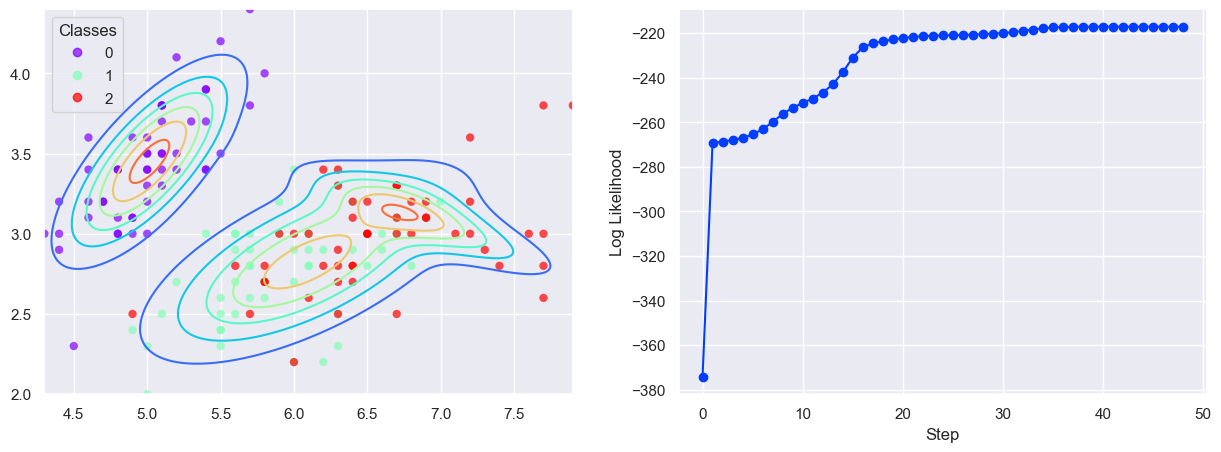

In [38]:
def create_animation(all_steps_em, data_x,iris_t):
    
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15,5))
    
    log_likelihoods = list(map(lambda x: x[3], all_steps_em))
    
    def animate(i):
        ax.cla()
        ax2.cla()
        
        predictions = all_steps_em[i][4]
        
        plot1 = plot_gaussian_mixtures(all_steps_em[i][0], all_steps_em[i][1], all_steps_em[i][2], iris_x, iris_t, target=ax)
                
        ax2.plot(list(range(i)), log_likelihoods[:i], '-o')
        plt.xlabel('Step')
        plt.ylabel('Log Likelihood')
        return plot1
    
    anim = FuncAnimation(
        fig, animate,
        frames=len(all_steps_em), interval=500, blit=True
    )
    return HTML(anim.to_html5_video())

create_animation(all_steps_em, iris_x,iris_t)

### 1.2) Nearest Centroid-based classification

Write a function

def nearest_centroid_based_class(x, mus, covariances):

that classifies a single data point x based on the nearest cluster centroid.

Inputs:

x: a single data point (a D-dimensional NumPy vector).

mus: the mean vectors for all clusters (shape (K, D)).

covariances: the covariance matrices for all clusters (shape (K, D, D)).

Requirement:

For each cluster, compute the distance between the point x and the cluster mean using the cluster’s covariance (the Mahalanobis distance — see Lecture 9, slide 23).

Collect the distances for all clusters.

Find the cluster with the smallest distance.

Output: Return the index (an integer between 0 and K-1) of the nearest cluster.

In [39]:
def nearest_centroid_based_class(x, mus, covariances):
    K = len(mus)
    dist_clusters = np.zeros(K)
    
    for k in range(K):
        temp = x-mus[k]
        dist_temp = temp @ np.linalg.inv(covariances[k]) @ temp.T
        dist_clusters[k] = dist_temp
    min_dist_index = np.argmin(dist_clusters)
    return min_dist_index

In the visualization below, a Gaussian Mixture Model (GMM) is fitted to the data using EM, and its parameters are combined with a nearest-centroid classifier (based on Mahalanobis distance). The animation shows how the model evolves over iterations.

The figure has two panels:

Left panel:

Plots the original Iris data (colored by their true class labels).

Overlays the current GMM parameters at each step: cluster means and covariance ellipses.

Shades the background using the nearest-centroid classifier built from the current GMM parameters. This shows the decision boundaries the classifier would use at that step.

Right panel:

Shows the log-likelihood curve over iterations, which reflects how well the GMM fits the data.

As the animation progresses, you can observe how:

The ellipses shift and reshape as the GMM updates.

The decision boundaries from the classifier move accordingly.

The log-likelihood increases until convergence.

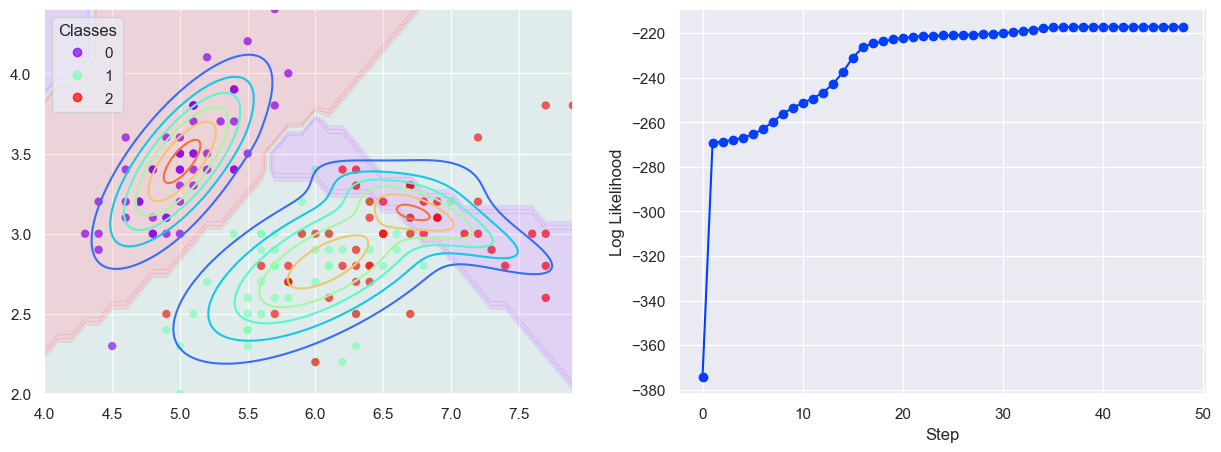

In [40]:
def create_animation_with_classifier(all_steps_em, data_x, iris_t):
    
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15,5))
    
    log_likelihoods = list(map(lambda x: x[3], all_steps_em))
    
    def animate(i):
        ax.cla()
        ax2.cla()
        
        predictions = all_steps_em[i][4]
        
        plot1 = plot_gaussian_mixtures(all_steps_em[i][0], all_steps_em[i][1], all_steps_em[i][2], iris_x, iris_t, target=ax)
        
        plot_mesh(
            lambda x: nearest_centroid_based_class(x, all_steps_em[i][0], all_steps_em[i][1]),
            n_class=len(all_steps_em[i][0]), target=ax
        )
        
        ax2.plot(list(range(i)), log_likelihoods[:i], '-o')
        plt.xlabel('Step')
        plt.ylabel('Log Likelihood')
        return plot1
    
    anim = FuncAnimation(
        fig, animate,
        frames=len(all_steps_em), interval=500, blit=True
    )
    return HTML(anim.to_html5_video())

create_animation_with_classifier(all_steps_em, iris_x, iris_t)

## 2) Principal Component Analysis

### 2.1) Generate data

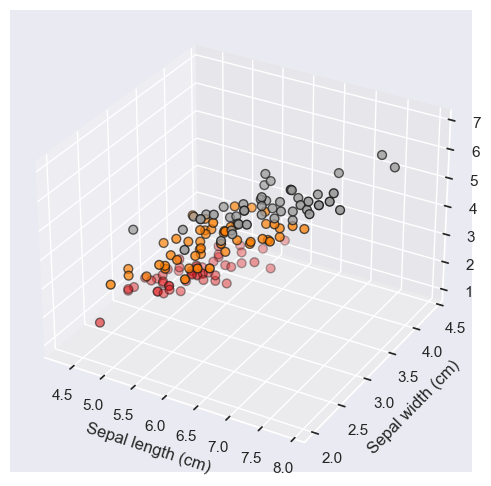

In [41]:
iris4_x = np.array(iris.data[:, :4])

def plot_classes_3d(data, classes,
                    labels=('Principal Component 1', 'Principal Component 2', 'Principal Component 3')):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot in 3D
    scatter = ax.scatter(data[:, 0], data[:, 1], data[:, 2],
                         c=classes, cmap=plt.cm.Set1, edgecolor='k', s=40)

    # Axis labels (pass `labels` to match what is actually plotted)
    ax.set_xlabel(labels[0])
    ax.set_ylabel(labels[1])
    ax.set_zlabel(labels[2])

    plt.show()

# This first plot shows the RAW first three iris features (no PCA yet),
# so the axes carry the feature names -- not principal components.
plot_classes_3d(iris4_x[:, :3], iris_t,
                labels=('Sepal length (cm)', 'Sepal width (cm)', 'Petal length (cm)'))

### 2.2) Apply PCA

Implement

def pca_projection(data, components):

Purpose Return the data projected onto the top components principal components (see Lecture 10, slides 7-10: maximum-variance formulation).

Inputs

data: NumPy array of shape (N, D) — N samples, D features.

components: int in [1, D] — number of components to keep.

Output

NumPy array of shape (N, components) — the projected data (same sample order).

In [42]:
def pca_projection(data, components):
    means_per_feature = np.mean(data, axis = 0) # (D, 1)
    centered_data = data - means_per_feature 
    cov_matrix = np.cov(centered_data, rowvar=False) # This tells NumPy that columns are features and rows are observations
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix) # It returns eigenvalues in ascending order, with matching eigenvectors stored as columns
    # Note that the eigenvectors are saved as columns:
    selected = eigenvectors[:, -components:][:, ::-1]
    # [:, -components:] keeps the eigenvectors with the largest eigenvalues.
    # [:, ::-1] reverses their column order, putting the direction with the most variance first.
    result = centered_data @ selected
    return result

### 2.3) Display projection

Projects the original 4-D Iris features to 2-D using PCA (PC1 vs PC2) and plots the result, coloring points by their true class labels with a legend.
a
Note: eigenvector signs are arbitrary (they depend on the numerical library), so your projection may appear mirrored along an axis compared to the sample solution — that is not an error.

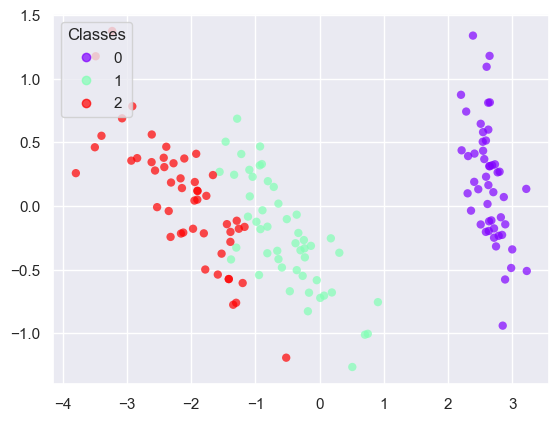

In [43]:
def plot_classes(data, classes, legend=True, target=plt):
    scatter = target.scatter(data[:, 0], data[:, 1], c=classes, alpha=0.7, cmap='rainbow', edgecolor='none')
    if legend:
        legend = target.legend(*scatter.legend_elements(), loc="upper left", title="Classes")
        return (scatter, legend)
    return (scatter, )

projected_data = pca_projection(iris4_x, 2)
plot_classes(projected_data, iris_t);

Projects the original 4-D Iris features to 3-D using PCA (PC1–PC3) and plots a 3D scatter of the projected points, colored by the true class labels.

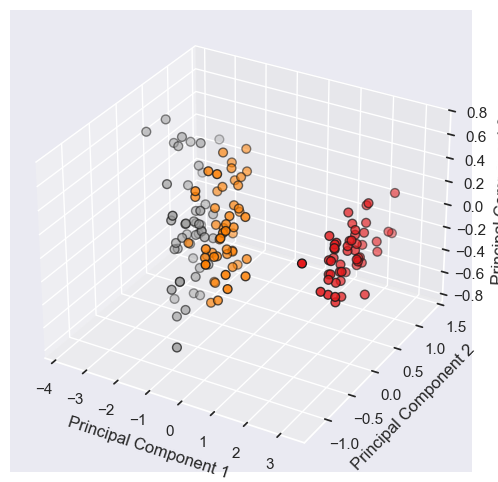

In [44]:
projected_data = pca_projection(iris4_x, 3)
plot_classes_3d(projected_data, iris_t)